In [1]:
!pip install --no-index seaborn

Looking in links: /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/gentoo2023/x86-64-v3, /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/gentoo2023/generic, /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/generic


In [8]:
import gzip
import numpy as np
import pandas as pd
from itertools import combinations
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from mpl_toolkits.axes_grid1 import make_axes_locatable

In [2]:
hla_vcf = '../data/1000G/HLA_typed/ALL.qc.no_monomorphic.vcf.gz'

In [3]:
# Load HLA allele matrix

header = None
samples = None

with gzip.open(hla_vcf, 'rt') as ifile:
    for line in ifile:
        if line.startswith("#CHROM"):
            header = line.rstrip().split('\t')
            assert len(header) > 9
            samples = header[9:]
            break

assert header is not None
assert samples is not None and len(samples) > 0

rows = []
for sample in samples:
    rows.append(dict())

with gzip.open(hla_vcf, 'rt') as ifile:
    for line in ifile:
        if line.startswith('#'): continue
        fields = dict(zip(header, line.rstrip().split('\t')))
        allele = fields['ID'].removeprefix('HLA-')

        # Keep only classical Class I and Class II
        if allele.split('*')[0] not in {'A', 'B', 'C', 'DPA1', 'DPB1', 'DQB1', 'DRA', 'DRB1'}: continue
        
        format_field = fields['FORMAT'].split(':')
        for i, sample in enumerate(samples):
            sample_field = dict(zip(format_field, fields[sample].split(':')))
            gt = sample_field['GT']
            if gt == './.':
                gt = np.nan
            else:
                gt = sum(float(x) for x in gt.split('/'))
            rows[i][allele] = gt
        
hla_df = pd.DataFrame(rows)

# check if no monomorphic
assert all(hla_df.var() > 0) 

# Remove alleles with MAC < 5
mac = hla_df.sum(axis=0)
hla_df = hla_df.loc[:, mac >= 5]

In [4]:
# correlation matrix
corr = hla_df.corr(method = "pearson")

# correlation matrix should have no NAs
assert corr.isna().sum().sum() == 0

print (corr.shape)

(283, 283)


/tmp/ipykernel_938178/1339795492.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  orig_cmap = plt.cm.get_cmap("RdBu_r")


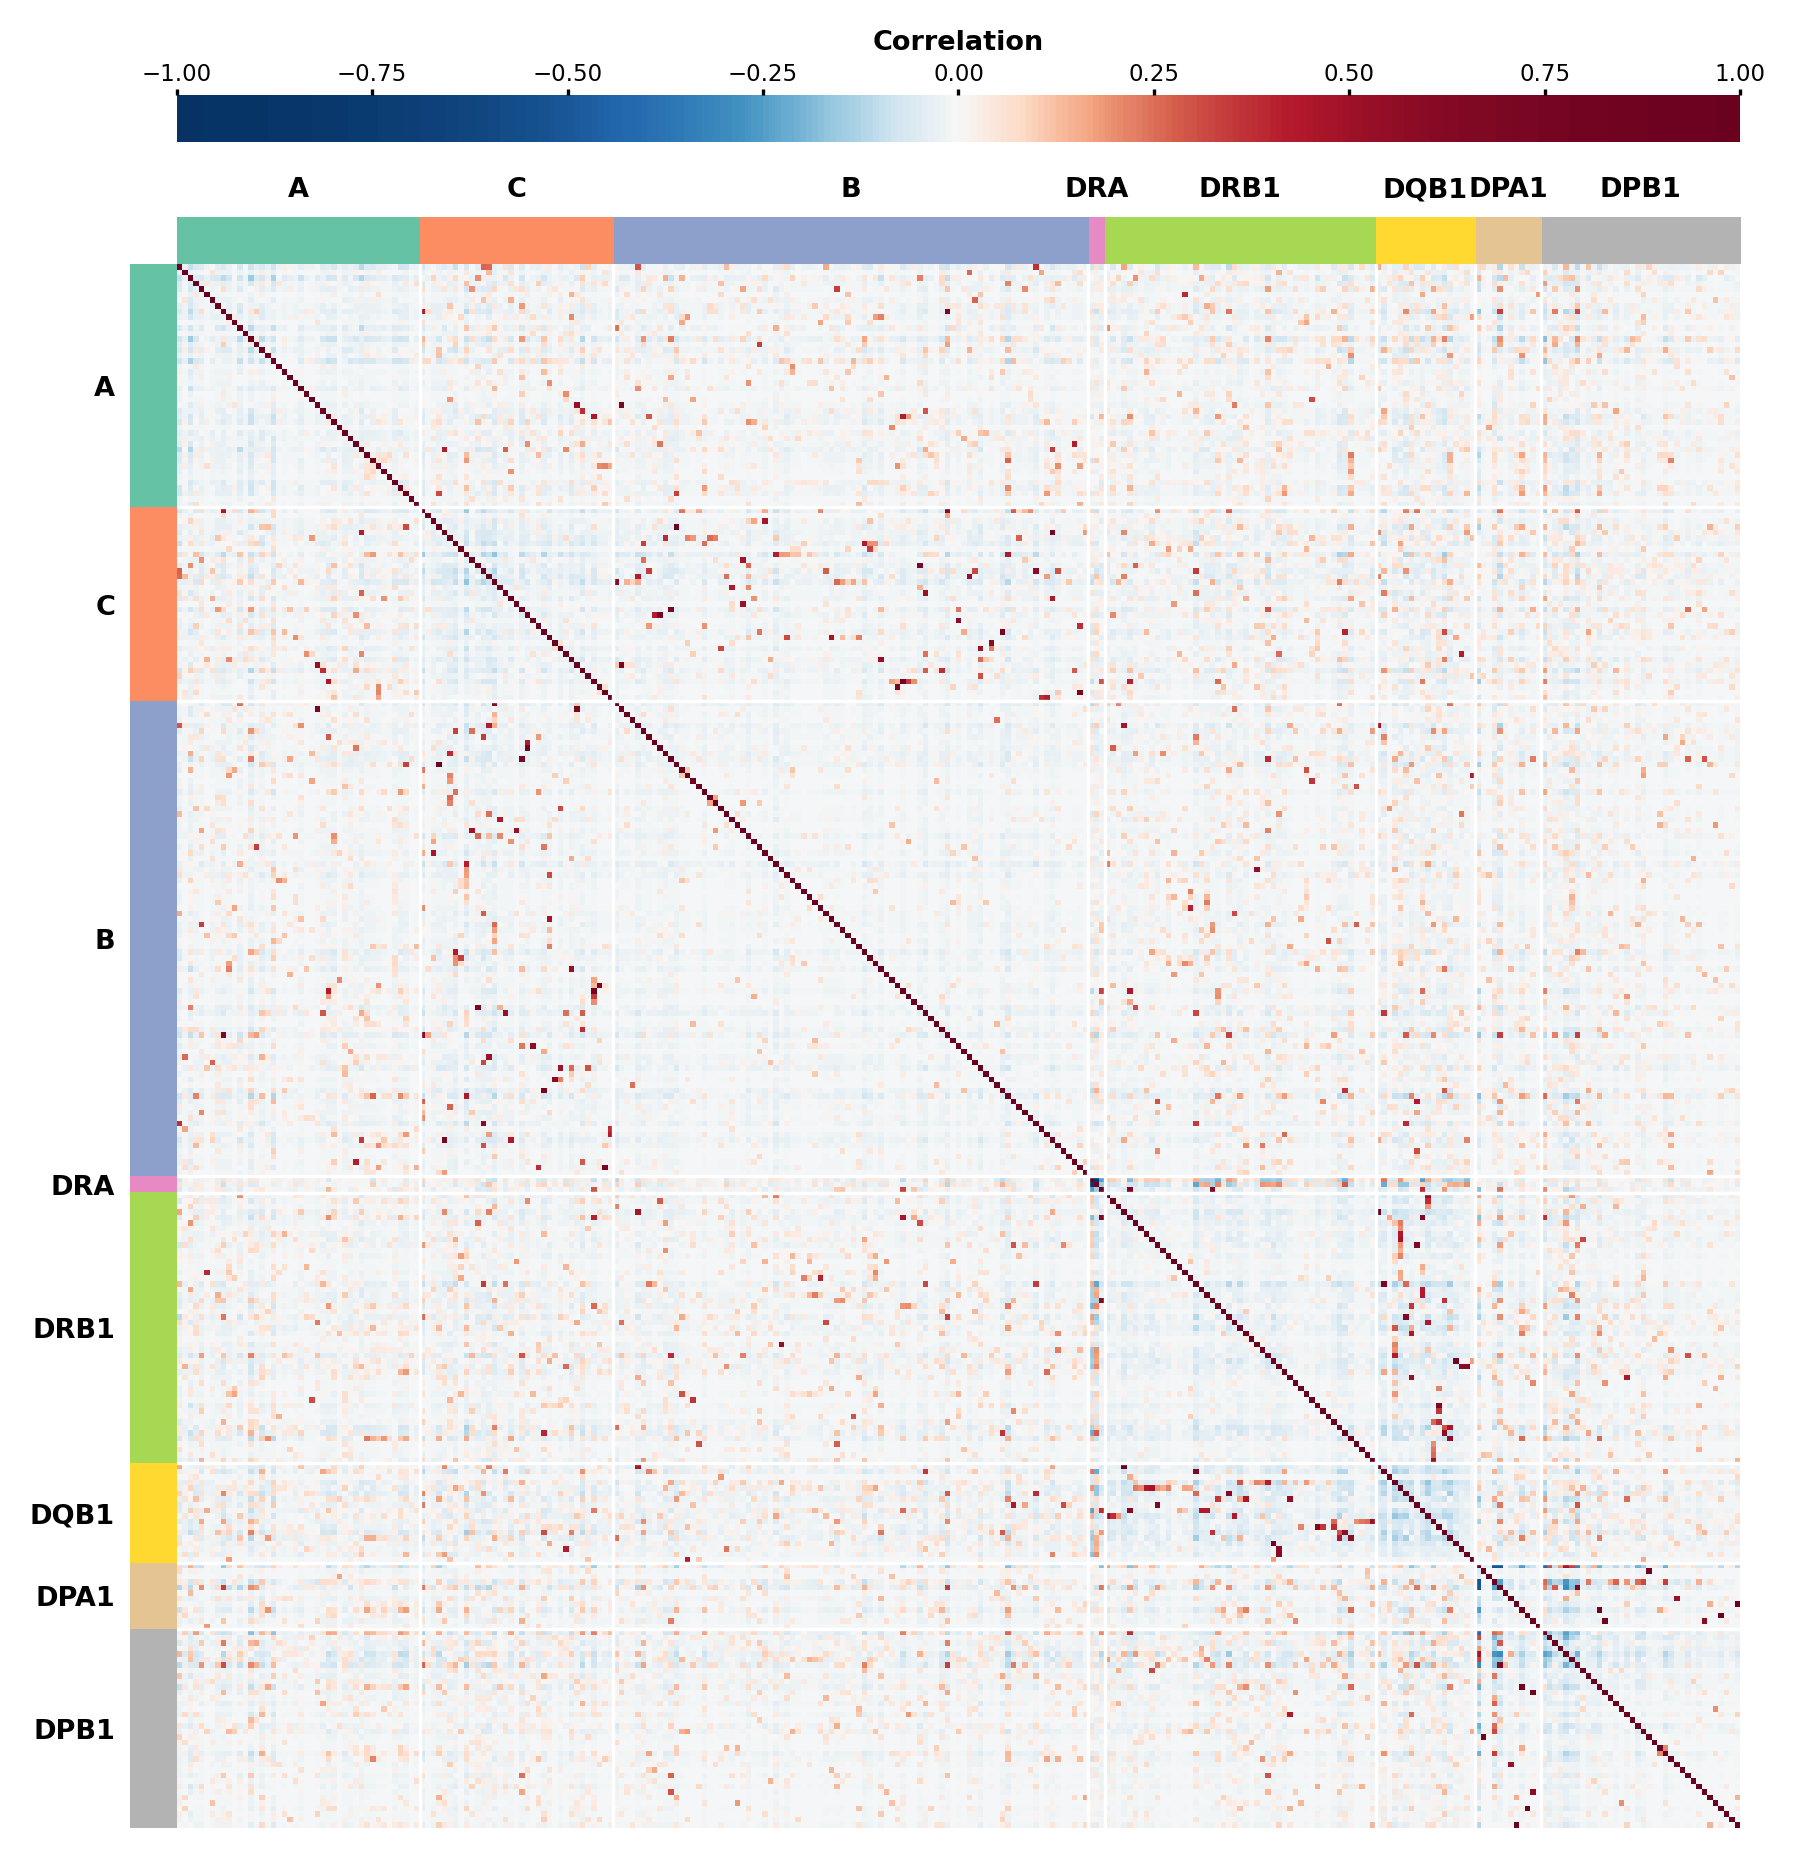

In [9]:
orig_cmap = plt.cm.get_cmap("RdBu_r")
colors = [orig_cmap(i) for i in np.linspace(0, 1, 256)]
x = np.linspace(0, 1, 256)
x_warped = 1 / (1 + np.exp(-10 * (x - 0.5)))
custom_cmap = LinearSegmentedColormap.from_list("HighContrastRdBu", orig_cmap(x_warped))

col_genes = [c.split("*")[0].replace("HLA-", "") for c in corr.columns]  # Clean names to just A, B, C...
unique_genes = []
gene_boundaries = [0]

for i, g in enumerate(col_genes):
    if i > 0 and g != col_genes[i-1]:
        unique_genes.append(col_genes[i-1])
        gene_boundaries.append(i)
unique_genes.append(col_genes[-1])
gene_boundaries.append(len(col_genes))

palette = sns.color_palette("Set2", len(unique_genes))
gene_color_map = dict(zip(unique_genes, palette))
cell_colors = [gene_color_map[g] for g in col_genes]

fig, ax_heatmap = plt.subplots(figsize=(7.5, 7.5), dpi=300)

divider = make_axes_locatable(ax_heatmap)

ax_top_color = divider.append_axes("top", size="3%", pad=0.0)
ax_left_color = divider.append_axes("left", size="3%", pad=0.0)
ax_cbar = divider.append_axes("top", size="3%", pad=0.25)

sns.heatmap(
    corr, 
    cmap=custom_cmap,
    center=0,
    vmin=-1,
    vmax=1,
    square=True, 
    cbar=True,
    cbar_ax=ax_cbar,
    cbar_kws={"orientation": "horizontal", "ticklocation": "top"},
    ax=ax_heatmap,
    xticklabels=False, 
    yticklabels=False
)

ax_cbar.tick_params(labelsize=5.5, pad=1, length=1.5)
ax_cbar.set_title("Correlation", fontsize=6.5, pad=3, fontweight="bold")

ax_top_color.imshow([cell_colors], aspect="auto", extent=[0, len(col_genes), 0, 1])
ax_left_color.imshow([[c] for c in cell_colors], aspect="auto", extent=[0, 1, len(col_genes), 0])

tick_positions = []
for i in range(len(unique_genes)):
    start = gene_boundaries[i]
    end = gene_boundaries[i+1]
    tick_positions.append((start + end) / 2)
    if end < len(col_genes):
        ax_heatmap.axvline(x=end, color="white", lw=0.8)
        ax_heatmap.axhline(y=end, color="white", lw=0.8)

ax_top_color.set_xlim(0, len(col_genes))
ax_top_color.set_xticks(tick_positions)
ax_top_color.set_xticklabels(unique_genes, fontsize=6.5, fontweight="bold")
ax_top_color.xaxis.tick_top()
ax_top_color.set_yticks([])

ax_left_color.set_ylim(len(col_genes), 0)
ax_left_color.set_yticks(tick_positions)
ax_left_color.set_yticklabels(unique_genes, fontsize=6.5, fontweight="bold")
ax_left_color.set_xticks([])

for ax_spine in [ax_top_color, ax_left_color]:
    for spine in ax_spine.spines.values():
        spine.set_visible(False)
    ax_spine.tick_params(size=0)

plt.show()


/tmp/ipykernel_938178/679777622.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  orig_cmap = plt.cm.get_cmap("RdBu_r")
/localscratch/dtaliun.65391299.0/lib/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/localscratch/dtaliun.65391299.0/lib/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


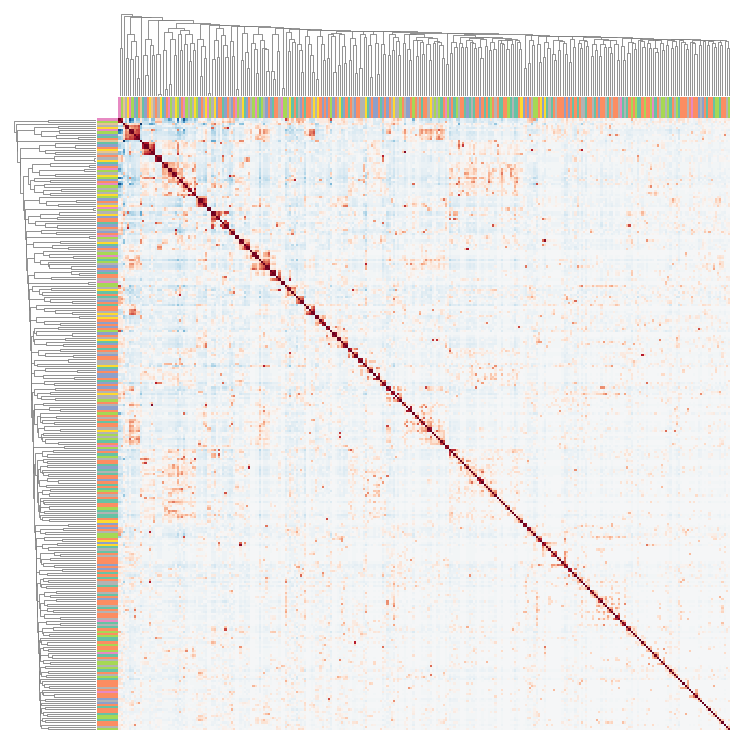

In [10]:
orig_cmap = plt.cm.get_cmap("RdBu_r")
x = np.linspace(0, 1, 256)
x_warped = 1 / (1 + np.exp(-10 * (x - 0.5)))
custom_cmap = LinearSegmentedColormap.from_list("HighContrastRdBu", orig_cmap(x_warped))

col_genes = [c.split("*")[0].replace("HLA-", "") for c in corr.columns]
unique_genes = sorted(list(set(col_genes)))

palette = sns.color_palette("Set2", len(unique_genes))
gene_color_map = dict(zip(unique_genes, palette))
tracking_colors = pd.Series(col_genes, index=corr.columns).map(gene_color_map)

g = sns.clustermap(
    corr,
    cmap=custom_cmap,
    center=0,
    vmin=-1,
    vmax=1,
    row_colors=tracking_colors,  
    col_colors=tracking_colors,  
    xticklabels=False,
    yticklabels=False,
    figsize=(7.5, 7.5),          
    dendrogram_ratio=(0.12, 0.12)
)

g.ax_cbar.set_visible(False)

g.ax_col_colors.set_xticks([])
g.ax_col_colors.set_yticks([])
g.ax_row_colors.set_xticks([])
g.ax_row_colors.set_yticks([])

plt.setp(g.ax_row_dendrogram.collections, linewidths=0.6, colors='grey')
plt.setp(g.ax_col_dendrogram.collections, linewidths=0.6, colors='grey')

plt.show()


In [11]:
# Compute Eigenvalues
eigvals = np.linalg.eigvalsh(corr)
eigvals = np.sort(eigvals)[::-1]


116


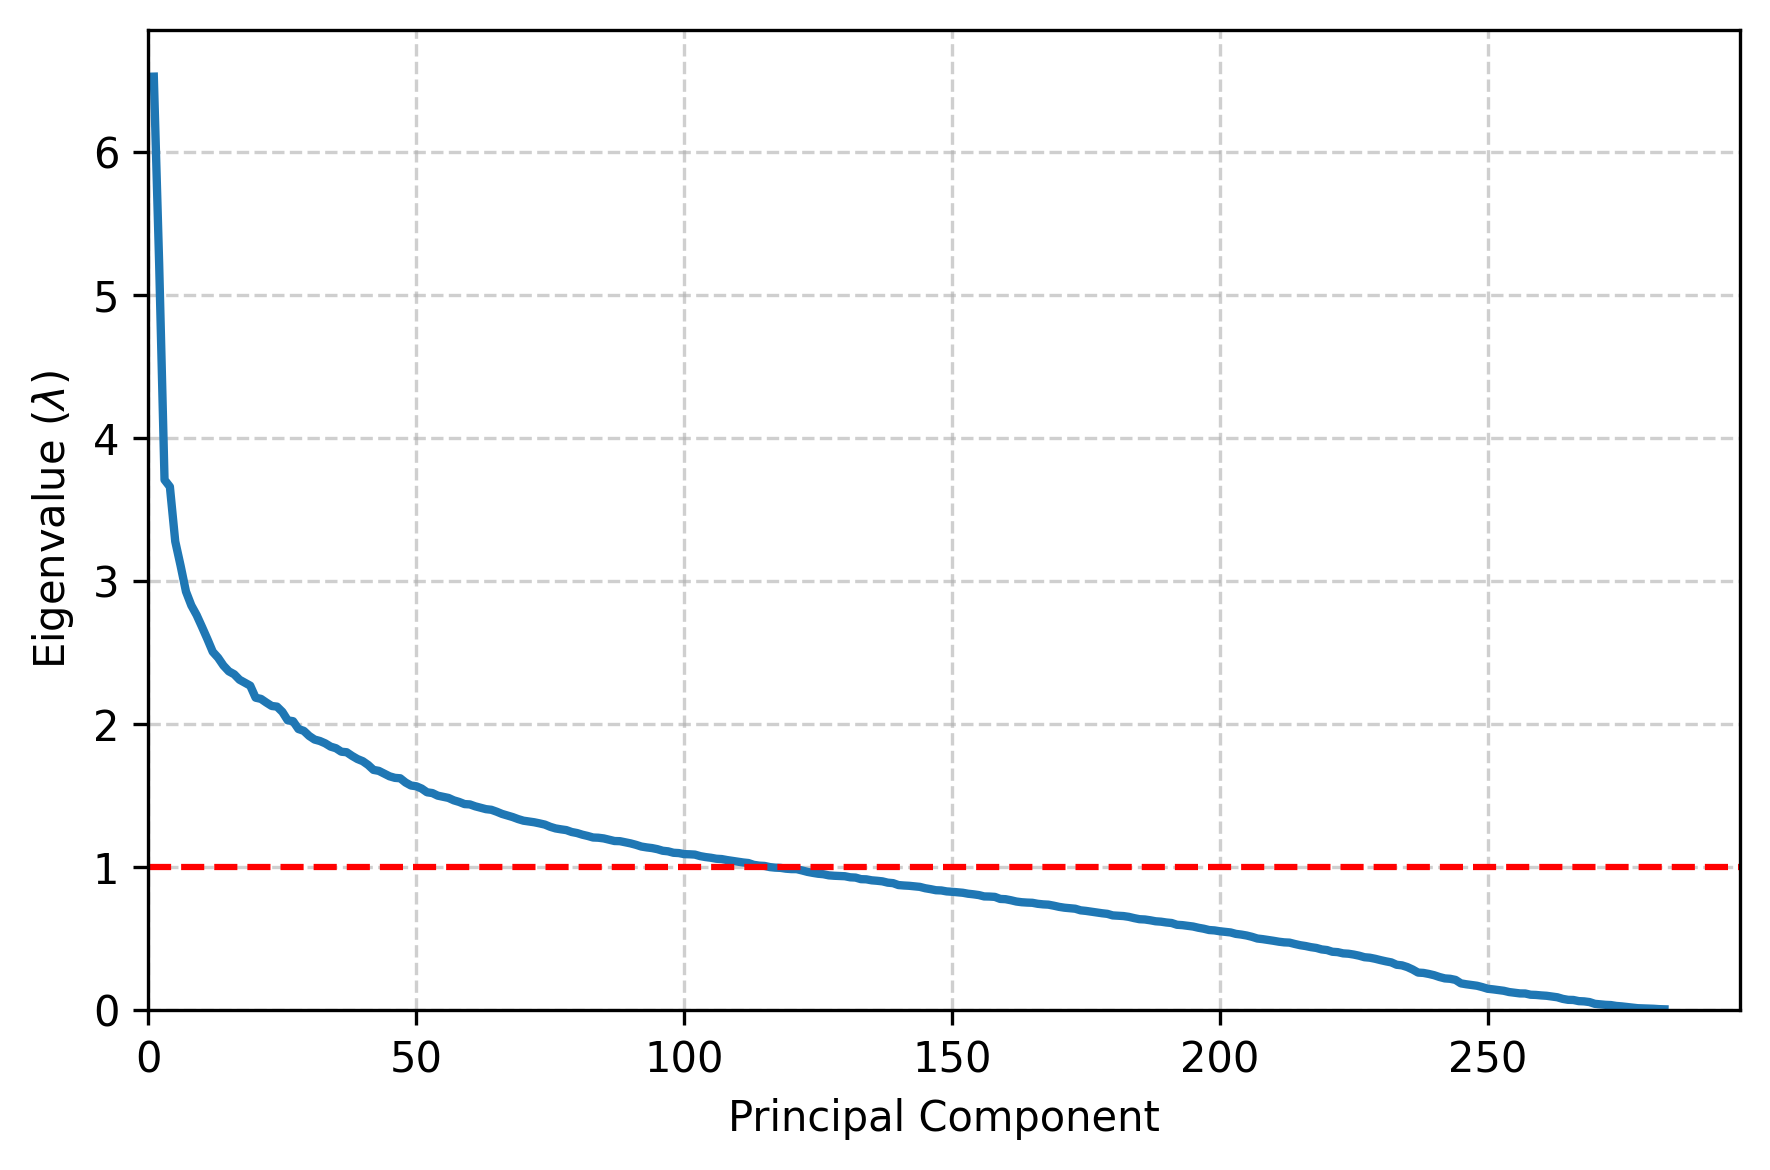

In [12]:
# Cite Scree plot: Cattell, R. B. (1966). The scree test for the number of factors. Multivariate Behavioral Research, 1(2), 245–276.
# Cite Kaiser Criterion Line: Kaiser, H. F. (1960). The application of electronic computers to factor analysis. Educational and Psychological Measurement, 20(1), 141–151.

print(sum(eigvals > 1))

fig, ax = plt.subplots(figsize = (6, 4), dpi = 300)

ax.plot(
    np.arange(1, len(eigvals)+1),
    eigvals,
    linewidth = 2,
)

ax.grid(True, which='major', axis='both', linestyle='--', alpha=0.6)

# 
ax.axhline(
    y = 1,
    color = 'red',
    linestyle = '--',
    linewidth = 1.5,
)

ax.set_xlabel('Principal Component')
ax.set_ylabel(r'Eigenvalue ($\lambda$)')

ax.set_ylim(bottom = 0)
ax.set_xlim(left = 0)

plt.tight_layout()
plt.show()


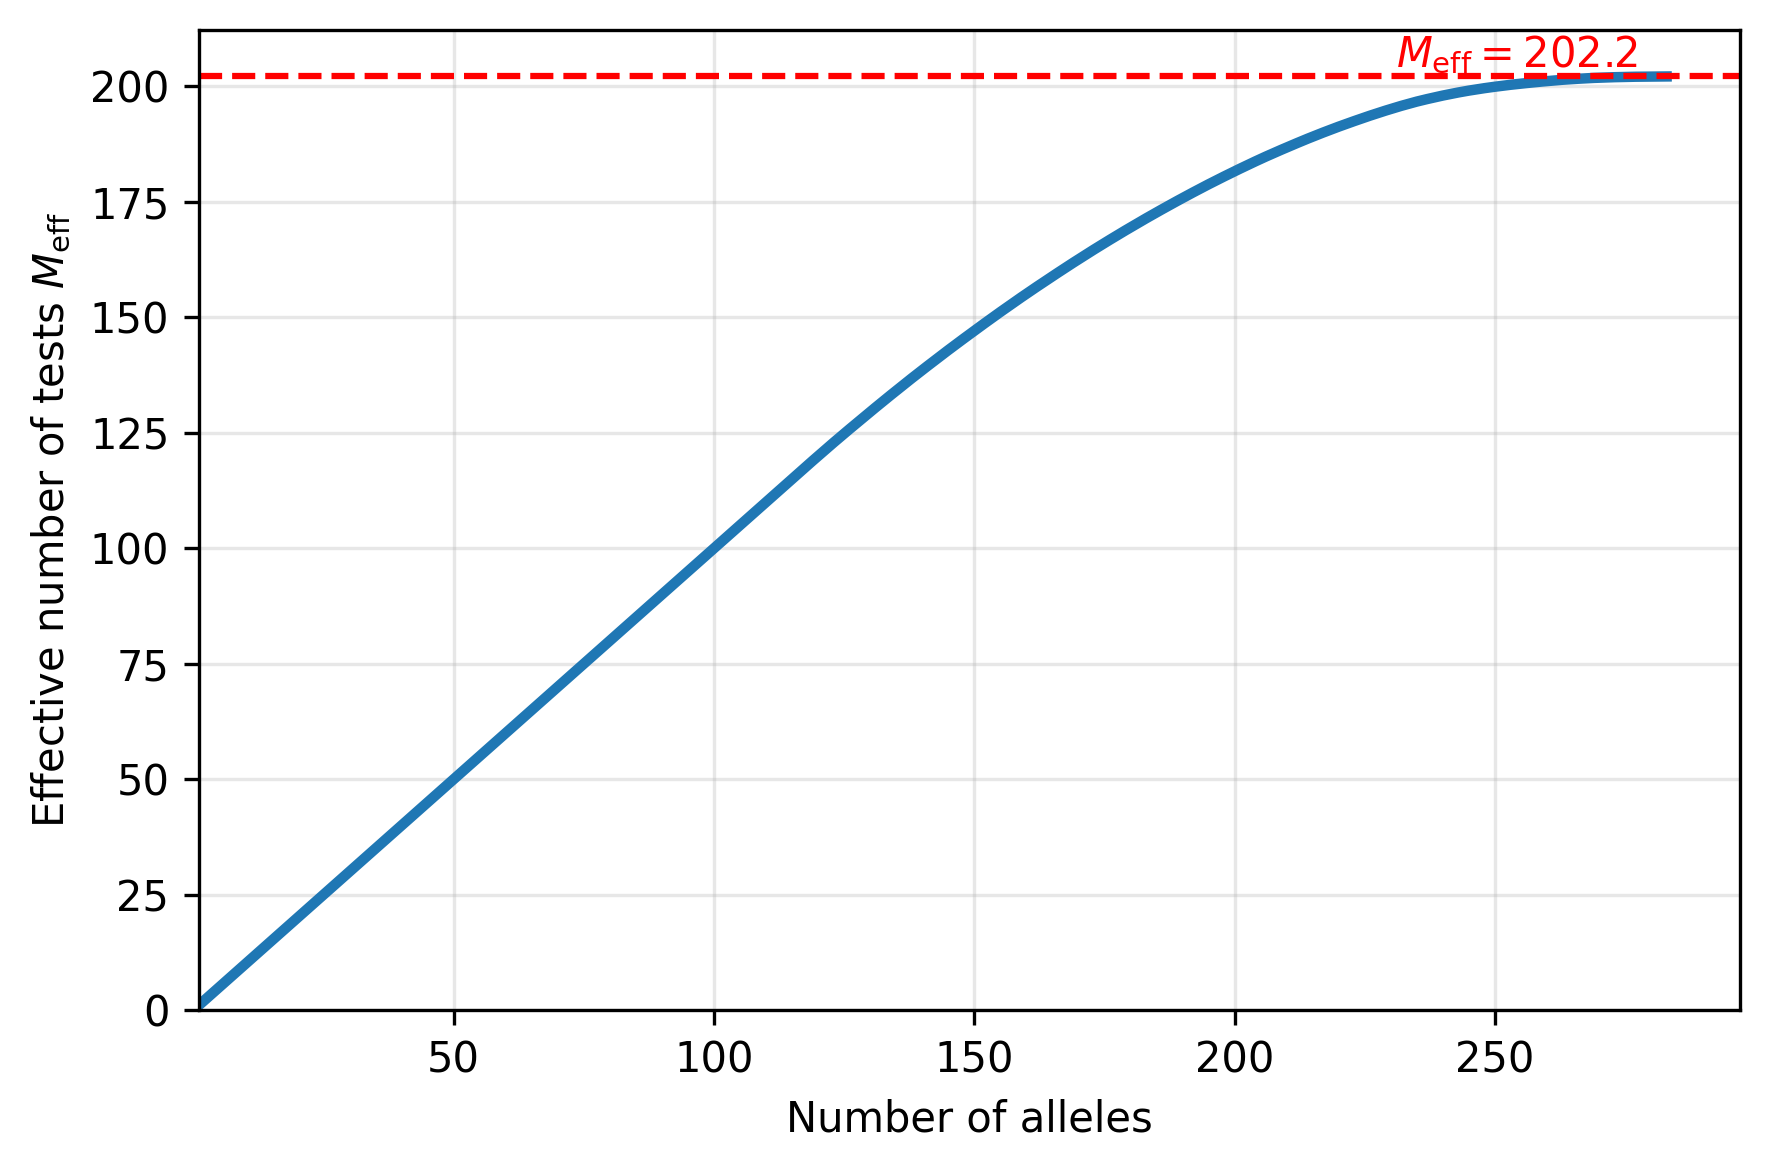

In [13]:
# Cite: Li, J., & Ji, L. (2005). Adjusting multiple testing in multilocus analyses using the eigenvalues of a correlation matrix. Behavior Genetics, 35(2), 221–227

fig, ax = plt.subplots(figsize = (6, 4), dpi = 300)

li_ji_contrib = np.minimum(eigvals, 1)
cum_meff = np.cumsum(li_ji_contrib)

ax.plot(
    np.arange(1, len(eigvals)+1),
    cum_meff,
    linewidth=2.5,
    color='C0'
)

final_meff = cum_meff[-1]

ax.axhline(
    final_meff,
    color='red',
    linestyle='--',
    linewidth=1.5
)

ax.text(
    0.98 * len(eigvals),
    final_meff,
    fr'$M_{{\rm eff}} = {final_meff:.1f}$',
    color='red',
    ha='right',
    va='bottom'
)

ax.grid(True, which='major', alpha=0.3)

ax.set_xlim(left = 1)
ax.set_ylim(bottom = 0)

ax.set_xlabel('Number of alleles')
ax.set_ylabel(r'Effective number of tests $M_{\rm eff}$')

plt.tight_layout()
plt.show()

In [14]:
# Collect correlation coefficient for alleles within the same gene and alleles between different genes.
within = []
between = []

for allele1, allele2 in combinations(corr.columns, 2):
    r = corr.loc[allele1, allele2]
    assert not pd.isna(r) # We made sure that there are no NAs in the correlation matrix because of MAC >= 5
    gene1 = allele1.split('*')[0]
    gene2 = allele2.split('*')[0]
    if gene1 == gene2:
        within.append(r)
    else:
        between.append(r)

within = np.array(within)
between = np.array(between)


/tmp/ipykernel_938178/2164162757.py:48: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([


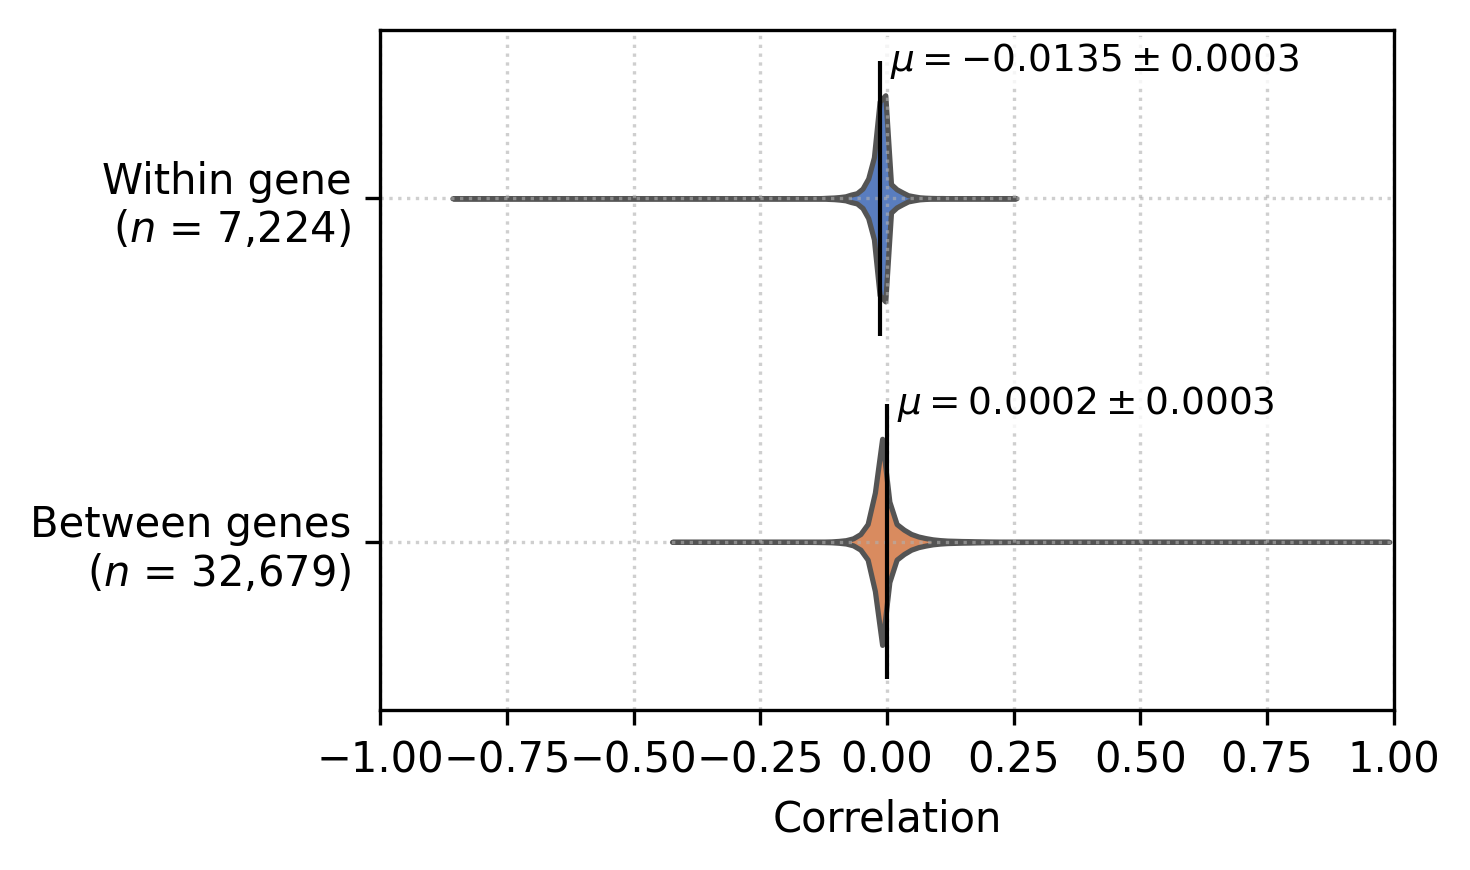

In [15]:
fig, ax = plt.subplots(figsize = (5, 3), dpi = 300)

plot_df = pd.DataFrame({
    "Correlation": np.concatenate([within, between]),
    "Type": (["Within gene"] * len(within)) +
            (["Between genes"] * len(between))
})

violinplot_order = ['Within gene', 'Between genes']

sns.violinplot(
    ax = ax,
    data = plot_df,
    x = "Correlation",
    y = "Type",
    hue = "Type",
    order = violinplot_order,
    inner = None,
    palette = "muted",
    width = 0.6,
    legend = False
)

stats = plot_df.groupby("Type")["Correlation"].agg(["mean", "sem"])
for i, category in enumerate(violinplot_order):
    mean_val = stats.loc[category, "mean"]
    se_val = stats.loc[category, "sem"]
    ax.vlines(x = mean_val, ymin = i - 0.4, ymax = i + 0.4, color = "black", linewidths = 1, linestyle = '-')

    ax.text(
        x = mean_val + 0.02, 
        y = i - 0.4,
        s=f"$\mu = {mean_val:.4f} \pm {se_val:.4f}$",
        color = "black",
        weight = "bold",
        ha = "left", 
        va = "center",
        fontsize = 9,
        bbox = dict(facecolor = 'white', alpha = 0.8, edgecolor = 'none', pad = 1)
    )


ax.set_xlim(-1, 1)

ax.grid(True, linestyle = ":", alpha = 0.6, zorder = 0)
ax.set_ylabel(None)

ax.set_yticklabels([
    f"Within gene\n($n$ = {len(within):,})", 
    f"Between genes\n($n$ = {len(between):,})"
])

plt.tight_layout()
plt.show()

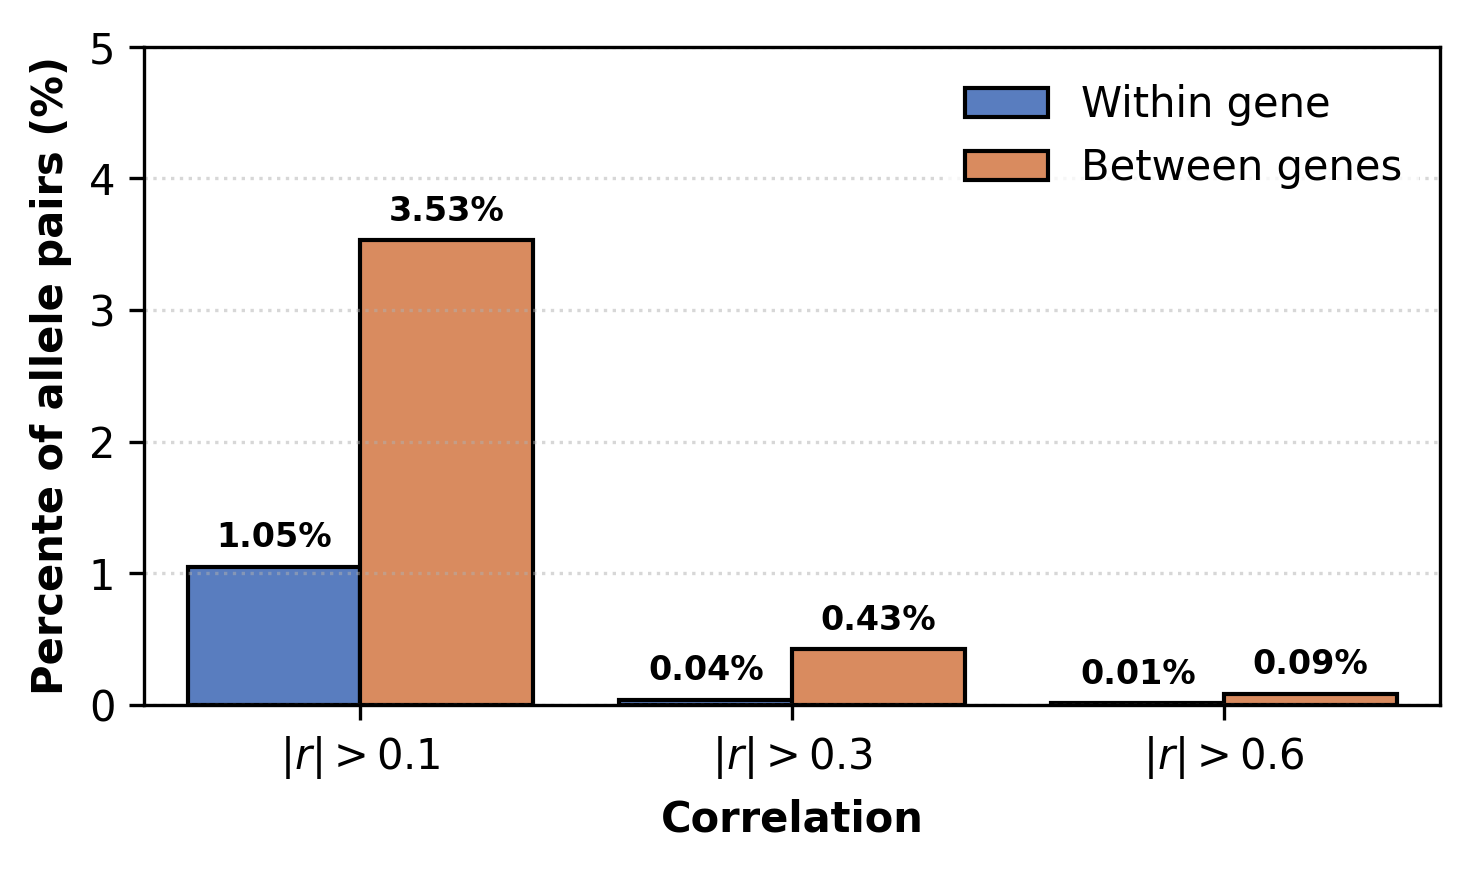

In [16]:
fig, ax = plt.subplots(figsize = (5, 3), dpi = 300)

thresholds = [0.1, 0.3, 0.6]

plot_df = []
for t in thresholds:
    within_pct = ((np.abs(within) > t).sum() / len(within)) * 100
    between_pct = ((np.abs(between) > t).sum() / len(between)) * 100
    plot_df.append({"Threshold": f"$|r| > {t}$", "Type": "Within gene", "Percentage": within_pct})
    plot_df.append({"Threshold": f"$|r| > {t}$", "Type": "Between genes", "Percentage": between_pct})
plot_df = pd.DataFrame(plot_df)

sns.barplot(
    ax = ax,
    data = plot_df,
    x = "Threshold",
    y = "Percentage",
    hue = "Type",
    hue_order = ["Within gene", "Between genes"],
    palette = "muted",
    edgecolor = "black",
    linewidth = 1
)

for container in ax.containers:
    ax.bar_label(
        container, 
        fmt = "%.2f%%", 
        label_type = "edge", 
        padding = 3, 
        fontsize = 8, 
        fontweight = "bold"
    )

ax.set_ylabel("Percente of allele pairs (%)", fontsize = 10, fontweight = "bold")
ax.set_xlabel("Correlation", fontsize = 10, fontweight = "bold")


ax.grid(True, axis="y", linestyle=":", alpha=0.5, zorder=0)
ax.set_ylim(0, 5) 

plt.legend(loc = "upper right", frameon = True, facecolor = "white", edgecolor = "none")
plt.tight_layout()
plt.show()


In [17]:
# Print top strongest (r > 0.6) positive correlations
upper = corr.where(
    np.triu(np.ones(corr.shape), k = 1).astype(bool)
)
for (allele1, allele2), r  in upper.stack().sort_values(ascending = False).items():
    if r < 0.6:
        break
    ac1 = hla_df[allele1].sum()
    ac2 = hla_df[allele2].sum()
    print(f'{allele1}\t{allele2}\t{ac1:.0f}\t{ac2:.0f}\t{r:.2f}')

DRB1*03:01	DQB1*02:01	320	320	0.98
DPA1*02:12	DPB1*85:01	24	26	0.96
C*02:10	B*15:03	95	88	0.92
DPA1*03:05	DPB1*40:01	24	20	0.92
DPA1*01:04	DPB1*15:01	14	18	0.88
DPA1*03:01	DPB1*105:01	180	171	0.88
DPA1*04:01	DPB1*107:01	34	24	0.83
DRB1*13:01	DQB1*06:03	233	189	0.82
C*17:01	B*42:01	108	71	0.82
C*12:02	B*52:01	162	176	0.77
C*08:02	B*14:02	97	62	0.76
C*18:01	B*81:01	14	29	0.74
A*29:01	B*07:05	35	34	0.74
A*02:07	B*46:01	112	144	0.74
C*15:05	B*07:05	66	34	0.73
C*08:01	B*15:02	149	91	0.72
C*17:03	B*41:02	17	19	0.72
C*03:02	B*58:01	132	180	0.71
DRB1*07:01	DQB1*02:02	531	496	0.70
C*05:01	B*44:02	155	116	0.69
DRB1*04:05	DQB1*04:01	105	49	0.68
DRA*01:03	DRB1*03:02	193	111	0.65
DRB1*14:04	DQB1*05:03	78	186	0.65
DPA1*02:02	DPB1*05:01	836	416	0.65
DRA*01:03	DRB1*08:03	193	86	0.63
DRB1*09:01	DQB1*03:03	274	359	0.62
DRB1*13:02	DQB1*06:09	212	94	0.61
DRB1*03:02	DQB1*04:02	111	262	0.60
